# Ours vs Ragnarok Baseline – Head-to-Head

Ranker comparison on the dicty goldset. Includes BGE-reranker-v2-m3 (our
main cross-encoder) and three alternates loaded as rerank-only swaps on the
shared first-stage retrieval pool: MS-MARCO MiniLM-L12 (lightweight),
MedCPT (domain-specific biomedical), and BGE-reranker-v2-Gemma (strong LLM reranker).
The Ragnarok BM25 + RankZephyr baseline is included as an external reference.

**Goldset:** `7a_dicty_gold_llm_public` (n=1,656 queries, full public split).

**Scope:**
1. First-stage retrieval — ours BM25+Dense fusion vs Ragnarok BM25 (Recall@K)
2. Reranking — full picture across all rerankers (MRR@K)
3. Per-query rerank impact (helped vs hurt) for each reranker

**Caveats:** Ragnarok BM25 is Pyserini/Anserini-tuned, ours is PyTerrier; the BM25
stage is therefore not a fully matched comparison. The intended comparison is at
the *design* level, not parameter-matched re-implementations. Ragnarok runs are
capped at top-100.

**Note on figure scope:** the multi-line MRR@K figure in §9 is the full research
picture — all rerankers on one axis. The paper main figure will use a curated
subset of these methods (decided once framing is locked).

## 1. Imports and Setup

In [153]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

## 2. Paths and Data Loading

In [154]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent
print("Base dir:", base_dir)

wdir = base_dir / "output" / "workflow_vega_7a_public_goldset_both_routes"
baseline_dir = base_dir / "output" / "ragnarok_baseline"
goldset_jsonl = base_dir / "output" / "dicty_gold_build" / "7a_dicty_gold_llm_public.jsonl"
output_dir = baseline_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
# Consolidated paper figures land here; diagnostic plots stay under output_dir.
paper_figures_dir = base_dir / "output" / "paper_figures"
paper_figures_dir.mkdir(parents=True, exist_ok=True)

SPLIT = "7a_dicty_gold_llm_public"

Base dir: /Users/yun/develop/dictycite


In [155]:
# Single shared color palette and label set for every method that appears in
# any plot in this notebook.
COLORS = {
    "ours_bm25":                "#1f77b4",
    "ours_fusion":              "#2ca02c",
    "ours_ce":                  "#d62728",
    "ours_postfusion":          "#9467bd",
    "vega_medcpt_ce":           "#8c564b",
    "frida_gemma_ce":           "#ff7f0e",
    "frida_ms_marco_minilm_ce": "#e377c2",
    "rag_bm25":                 "#1f77b4",
    "rag_rerank":               "#17becf",
}
LABELS = {
    "ours_bm25":                "Ours: BM25",
    "ours_fusion":              "Ours: BM25+Dense Fusion",
    "ours_ce":                  "Ours: BGE-reranker-v2-m3",
    "ours_postfusion":          "Ours: Post-rerank Fusion",
    "vega_medcpt_ce":           "Ours: MedCPT (rerank-only)",
    "frida_gemma_ce":           "Ours: BGE-reranker-v2-Gemma (rerank-only)",
    "frida_ms_marco_minilm_ce": "Ours: MS MARCO MiniLM (rerank-only)",
    "rag_bm25":                 "Ragnarok: BM25",
    "rag_rerank":               "Ragnarok: BM25 + RankZephyr",
}

## 3. Load Qrels and Run Files

In [156]:
def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    return doc_entry.rsplit("/", 1)[-1] if "/" in doc_entry else doc_entry


def load_qrels(path: Path) -> dict[str, set[str]]:
    qrels: dict[str, set[str]] = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            pmids = {_extract_pmid(d) for d in q.get("documents", []) if _extract_pmid(d)}
            if qid and pmids:
                qrels[qid] = pmids
    return qrels


def load_query_ids_without_any_abstract_insufficient_doc(path: Path) -> set[str]:
    """Query IDs where no cited doc has evidence_level abstract_insufficient (abstract-eval subset)."""
    out: set[str] = set()
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            if not qid:
                continue
            if any(
                (d.get("evidence_level") or "").strip() == "abstract_insufficient"
                for d in (q.get("docs") or [])
            ):
                continue
            out.add(qid)
    return out


qrels = load_qrels(goldset_jsonl)
print(f"Loaded qrels: {len(qrels)} queries")

qids_no_abstract_insufficient = load_query_ids_without_any_abstract_insufficient_doc(goldset_jsonl)
n_qrels_abstract_only = len(set(qrels) & qids_no_abstract_insufficient)
print(
    f"Queries with no abstract_insufficient doc (intersect qrels): {n_qrels_abstract_only} / {len(qrels)}"
)

Loaded qrels: 1656 queries
Queries with no abstract_insufficient doc (intersect qrels): 1269 / 1656


In [157]:
def load_run_tsv(path: Path) -> dict[str, list[str]]:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols["qid"]
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return {str(qid): g[doc_col].tolist() for qid, g in df.groupby(qid_col, sort=False)}


def load_run_trec(path: Path) -> dict[str, list[str]]:
    """TREC 6-col format: qid Q0 docid rank score tag (whitespace separated)."""
    df = pd.read_csv(
        path, sep=r"\s+", header=None,
        names=["qid", "Q0", "docid", "rank", "score", "tag"],
        engine="python",
    )
    df["qid"] = df["qid"].astype(str)
    df["docid"] = df["docid"].astype(str)
    df = df.sort_values(["qid", "rank"])
    return {str(qid): g["docid"].tolist() for qid, g in df.groupby("qid", sort=False)}


def _resolve_cross_encoder_run_tsv(workflow_root: Path) -> Path:
    runs_dir = workflow_root / "rerank" / "cross_encoder" / "runs"
    preferred = runs_dir / "best_rrf_7a_dicty_gold_llm_public_top5000.tsv"
    if preferred.is_file():
        return preferred
    candidates = sorted(runs_dir.glob("best_rrf*.tsv"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(
        f"no TSV in {runs_dir} (expected best_rrf_7a_dicty_gold_llm_public_top5000.tsv or best_rrf*.tsv)"
    )


# Required runs (always loaded)
runs: dict[str, dict[str, list[str]]] = {
    "ours_bm25":       load_run_tsv(wdir / "retrieval" / "bm25" / "runs" / "BM25__7a_dicty_gold_llm_public__top5000.tsv"),
    "ours_fusion":     load_run_tsv(wdir / "retrieval" / "fusion" / "runs" / "best_rrf_7a_dicty_gold_llm_public_top5000.tsv"),
    "ours_ce":         load_run_tsv(wdir / "rerank" / "cross_encoder" / "runs" / "best_rrf_7a_dicty_gold_llm_public_top5000.tsv"),
    "ours_postfusion": load_run_tsv(wdir / "rerank" / "post_rerank_fusion" / "runs" / "best_rrf_7a_dicty_gold_llm_public_top5000_rrf_poolR50_poolH50_k60.tsv"),
    "rag_bm25":        load_run_trec(baseline_dir / "runs" / "bm25_run.txt"),
    "rag_rerank":      load_run_trec(baseline_dir / "runs" / "rerank_run.txt"),
}

# Alternate rerankers (rerank-only on a shared first-stage retrieval pool); skipped if missing.
for key, root in (
    ("vega_medcpt_ce", base_dir / "output" / "workflow_vega_7a_public_goldset_rerank_medcpt"),
    ("frida_gemma_ce", base_dir / "output" / "workflow_frida_7a_public_goldset_rerank_gemma"),
    (
        "frida_ms_marco_minilm_ce",
        base_dir / "output" / "workflow_frida_7a_public_goldset_rerank_ms_marco_minilm",
    ),
):
    try:
        p = _resolve_cross_encoder_run_tsv(root)
        runs[key] = load_run_tsv(p)
    except FileNotFoundError as e:
        print(f"Skip {key}: {e}")

for name, run in runs.items():
    print(f"{name:18s}: {len(run)} qids")

ours_bm25         : 1656 qids
ours_fusion       : 1656 qids
ours_ce           : 1656 qids
ours_postfusion   : 1656 qids
rag_bm25          : 1656 qids
rag_rerank        : 1656 qids
vega_medcpt_ce    : 1656 qids
frida_gemma_ce    : 1656 qids
frida_ms_marco_minilm_ce: 1656 qids


## 4. Metric Helpers

In [158]:
def recall_at_k(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    return sum(1 for d in docs[:k] if d in rels) / len(rels)


def mrr_at_k(docs: list[str], rels: set[str], k: int) -> float:
    for i, doc in enumerate(docs[:k], 1):
        if doc in rels:
            return 1.0 / i
    return 0.0


def mean_at_ks(run, qrels_, ks, fn) -> dict[int, float]:
    per_q = {k: [] for k in ks}
    for qid, docs in run.items():
        rels = qrels_.get(qid)
        if not rels:
            continue
        for k in ks:
            per_q[k].append(fn(docs, rels, k))
    return {k: float(np.mean(v)) if v else 0.0 for k, v in per_q.items()}


def _per_query_mrr_at_k(run: dict[str, list[str]], qrels_: dict[str, set[str]], k: int) -> dict[str, float]:
    out: dict[str, float] = {}
    for qid, rels in qrels_.items():
        docs = run.get(qid, [])
        out[qid] = mrr_at_k(docs, rels, k)
    return out

## 5. Headline Summary Table

All methods on one table, including alternate rerankers when present.

In [159]:
summary_methods_all = [
    "ours_bm25", "ours_fusion",
    "ours_ce", "vega_medcpt_ce", "frida_gemma_ce", "frida_ms_marco_minilm_ce", "ours_postfusion",
    "rag_bm25", "rag_rerank",
]
summary_methods = [m for m in summary_methods_all if m in runs]

recall_ks_short = [10, 50, 100]
mrr_ks_short = [1, 5, 10]

rows = []
for m in summary_methods:
    rec = mean_at_ks(runs[m], qrels, recall_ks_short, recall_at_k)
    mr = mean_at_ks(runs[m], qrels, mrr_ks_short, mrr_at_k)
    rows.append({
        "method": LABELS[m],
        **{f"Recall@{k}": rec[k] for k in recall_ks_short},
        **{f"MRR@{k}": mr[k] for k in mrr_ks_short},
    })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
summary_df.to_csv(output_dir / "summary_table.csv", index=False)

                                   method  Recall@10  Recall@50  Recall@100  MRR@1  MRR@5  MRR@10
                               Ours: BM25     0.7036     0.8037      0.8407 0.5175 0.5863  0.5933
                  Ours: BM25+Dense Fusion     0.7080     0.8370      0.8704 0.4825 0.5583  0.5678
                 Ours: BGE-reranker-v2-m3     0.7321     0.8471      0.8809 0.5199 0.5984  0.6052
               Ours: MedCPT (rerank-only)     0.7896     0.8849      0.9083 0.5568 0.6437  0.6504
Ours: BGE-reranker-v2-Gemma (rerank-only)     0.8040     0.8937      0.9133 0.6304 0.7026  0.7073
      Ours: MS MARCO MiniLM (rerank-only)     0.6686     0.7906      0.8257 0.4565 0.5339  0.5413
                 Ours: Post-rerank Fusion     0.7528     0.8471      0.8837 0.5302 0.6132  0.6202
                           Ragnarok: BM25     0.7133     0.8205      0.8503 0.5290 0.5970  0.6041
              Ragnarok: BM25 + RankZephyr     0.6914     0.8321      0.8503 0.4789 0.5586  0.5660


## 6. First-stage Retrieval: Recall@K

Ours BM25+Dense fusion vs Ragnarok BM25. Ragnarok BM25 retrieves top-100, so
the curve is plotted up to K=100.

*Note:* Alternate CE rerankers (MedCPT, BGE-reranker-v2-Gemma, MS MARCO MiniLM) are
rerank-only and reuse the same first-stage retrieval pool — they do not change
Recall@K, only the ordering within the pool. Recall@K is therefore a property
of the first stage alone.

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/01_retrieval_recall.png


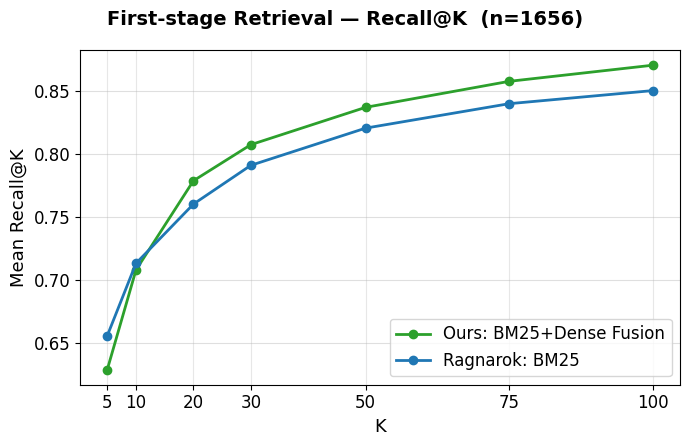

In [160]:
recall_ks = [5, 10, 20, 30, 50, 75, 100]
retrieval_methods = ["ours_fusion", "rag_bm25"]

retrieval_recall = {m: mean_at_ks(runs[m], qrels, recall_ks, recall_at_k) for m in retrieval_methods}

fig, ax = plt.subplots(figsize=(7, 4.5))
for m in retrieval_methods:
    vals = [retrieval_recall[m][k] for k in recall_ks]
    ax.plot(
        recall_ks, vals,
        marker="o", markersize=6, linewidth=2.0,
        color=COLORS[m], label=LABELS[m],
    )

ax.set_xlabel("K")
ax.set_ylabel("Mean Recall@K")
ax.set_xticks(recall_ks)
ax.set_xticklabels([str(k) for k in recall_ks])
ax.grid(True, axis="y", alpha=0.4)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(fontsize=12, loc="lower right")
fig.suptitle(f"First-stage Retrieval — Recall@K  (n={len(qrels)})", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = output_dir / "01_retrieval_recall.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 7. Full Pipeline vs Ragnarok: Reranking MRR@K

Ours CrossEncoder and Post-rerank Fusion vs Ragnarok+RankZephyr listwise.
The first-stage fusion is shown as a thin gray reference so the rerank delta
is visible.

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/02_rerank_mrr.png


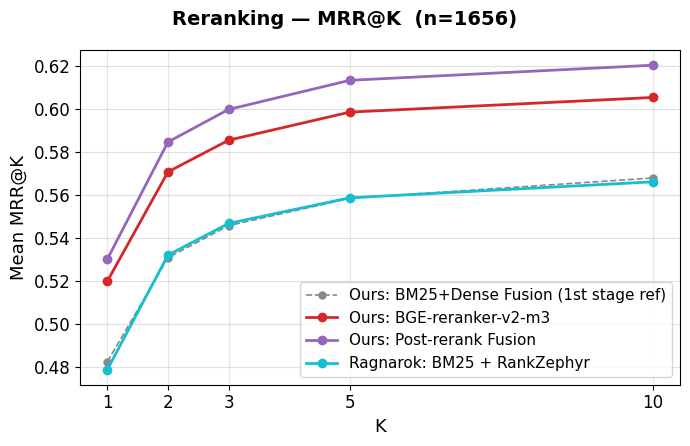

In [161]:
mrr_ks = [1, 2, 3, 5, 10]
rerank_methods = ["ours_fusion", "ours_ce", "ours_postfusion", "rag_rerank"]

rerank_mrr = {m: mean_at_ks(runs[m], qrels, mrr_ks, mrr_at_k) for m in rerank_methods}

fig, ax = plt.subplots(figsize=(7, 4.5))

# Reference: first-stage fusion as a thin gray dashed line
ref_vals = [rerank_mrr["ours_fusion"][k] for k in mrr_ks]
ax.plot(
    mrr_ks, ref_vals,
    marker="o", markersize=5, linewidth=1.2,
    color="#888888", linestyle="--",
    label=LABELS["ours_fusion"] + " (1st stage ref)",
)

for m in ["ours_ce", "ours_postfusion", "rag_rerank"]:
    vals = [rerank_mrr[m][k] for k in mrr_ks]
    ax.plot(
        mrr_ks, vals,
        marker="o", markersize=6, linewidth=2.0,
        color=COLORS[m], label=LABELS[m],
    )

ax.set_xlabel("K")
ax.set_ylabel("Mean MRR@K")
ax.set_xticks(mrr_ks)
ax.set_xticklabels([str(k) for k in mrr_ks])
ax.grid(True, axis="y", alpha=0.4)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(fontsize=11, loc="lower right")
fig.suptitle(f"Reranking — MRR@K  (n={len(qrels)})", fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = output_dir / "02_rerank_mrr.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 8. Headline Bar — MRR@10 and Recall@100 Side-by-Side

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/03_headline_bar.png


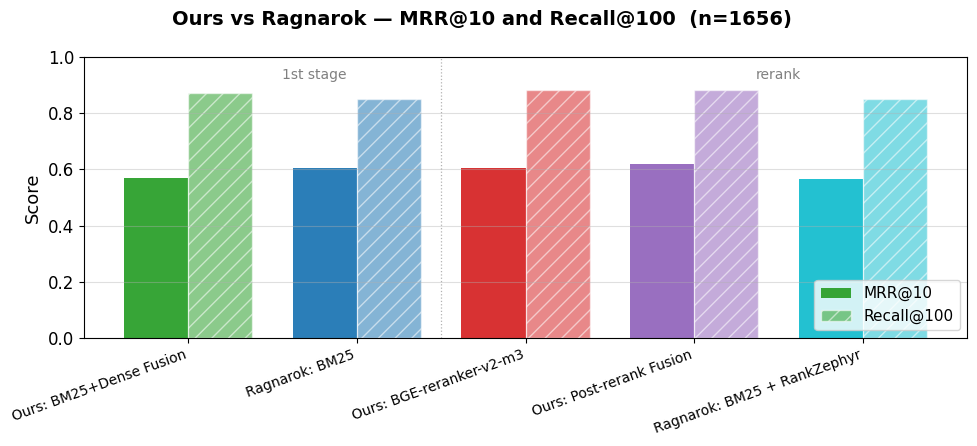

In [162]:
bar_methods_all = ["ours_fusion", "rag_bm25", "ours_ce", "ours_postfusion", "rag_rerank"]
bar_methods = [m for m in bar_methods_all if m in runs]

mrr10 = {m: mean_at_ks(runs[m], qrels, [10], mrr_at_k)[10] for m in bar_methods}
rec100 = {m: mean_at_ks(runs[m], qrels, [100], recall_at_k)[100] for m in bar_methods}

x = np.arange(len(bar_methods))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width / 2, [mrr10[m] for m in bar_methods], width,
       color=[COLORS[m] for m in bar_methods], alpha=0.95, label="MRR@10")
ax.bar(x + width / 2, [rec100[m] for m in bar_methods], width,
       color=[COLORS[m] for m in bar_methods], alpha=0.55, label="Recall@100",
       hatch="//", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([LABELS[m] for m in bar_methods], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.axvline(x=1.5, color="gray", linestyle=":", linewidth=0.9, alpha=0.6)
ax.text(0.75, 0.96, "1st stage", fontsize=10, color="gray", ha="center", va="top",
        transform=ax.get_xaxis_transform())
ax.text(3.5, 0.96, "rerank", fontsize=10, color="gray", ha="center", va="top",
        transform=ax.get_xaxis_transform())
ax.grid(True, axis="y", alpha=0.4)
ax.legend(fontsize=11, loc="lower right")
fig.suptitle(f"Ours vs Ragnarok — MRR@10 and Recall@100  (n={len(qrels)})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig_path = output_dir / "03_headline_bar.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 9. Ranker Comparison — MRR@K (paper Fig 3 main + supp Fig S2)

Two figures generated from the same data:

- **Paper main (Fig 3 candidate)** — 5 lines: BM25 + 4 cross-encoder rerankers
  (MS-MARCO MiniLM, BGE-reranker-v2-m3, MedCPT, BGE-reranker-v2-Gemma). The headline:
  ranker choice in domain RAG matters — a lightweight CE *hurts*, a mid-tier
  CE barely helps, domain/strong CEs help meaningfully.
- **Paper supplement (Fig S2 candidate)** — same 5 lines plus first-stage
  Fusion and Ragnarok+RankZephyr (external reference). For completeness;
  reviewers who want to see the full picture get one figure with everything.

All four CEs operate on the BM25+Dense fusion candidate pool.

Saved: /Users/yun/develop/dictycite/output/paper_figures/fig3_main_ranker_comparison.png


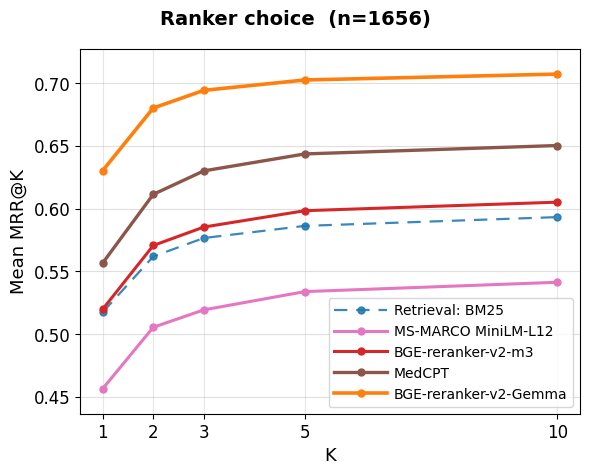

Saved: /Users/yun/develop/dictycite/output/paper_figures/fig_s2_full_ranker_comparison.png


/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_89479/923166741.py:134: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.58, 0.93])


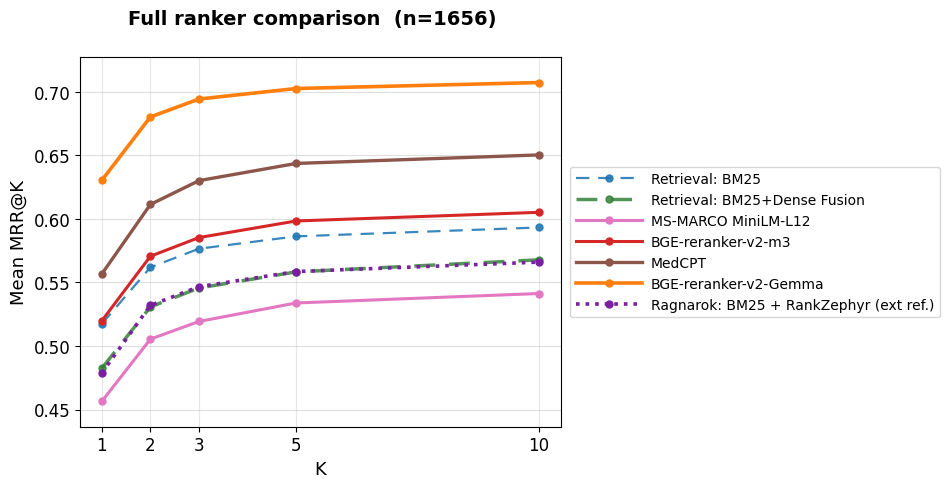


MRR@10 deltas vs BM25 (Fig S2 full set):
  ours_bm25                      MRR@10=0.5933  delta=+0.0000
  ours_fusion                    MRR@10=0.5678  delta=-0.0255
  frida_ms_marco_minilm_ce       MRR@10=0.5413  delta=-0.0520
  ours_ce                        MRR@10=0.6052  delta=+0.0119
  vega_medcpt_ce                 MRR@10=0.6504  delta=+0.0571
  frida_gemma_ce                 MRR@10=0.7073  delta=+0.1140
  rag_rerank                     MRR@10=0.5660  delta=-0.0273


In [163]:
fig9_ks = [1, 2, 3, 5, 10]

# Method styles (one place; both figures pick subsets).
# Tuple linestyle (0, (on, off, ...)) reads reliably in the legend (short handlelength makes "--" look solid).
# Same marker shape for every series (circles). BM25 and BM25+Dense fusion share one dash pattern; Ragnarok
# is purple with a different rhythm (dotted vs dashed) plus z-order so it stays visible when curves cross fusion.
_DASH_RETRIEVAL = (0, (6, 4))

ALL_METHOD_STYLE: dict[str, dict] = {
    "ours_bm25": {
        "color": "#1f77b4",
        "linewidth": 1.6,
        "linestyle": _DASH_RETRIEVAL,
        "alpha": 0.88,
        "zorder": 2,
        "marker": "o",
        "markersize": 5,
        "label": "Retrieval: BM25",
    },
    "ours_fusion": {
        "color": "#2e7d32",
        "linewidth": 2.5,
        "linestyle": _DASH_RETRIEVAL,
        "alpha": 0.82,
        "zorder": 3,
        "marker": "o",
        "markersize": 5,
        "label": "Retrieval: BM25+Dense Fusion",
    },
    "frida_ms_marco_minilm_ce": {
        "color": "#e377c2",
        "linewidth": 2.2,
        "linestyle": "-",
        "alpha": 1.0,
        "zorder": 4,
        "marker": "o",
        "markersize": 5,
        "label": "MS-MARCO MiniLM-L12",
    },
    "ours_ce": {
        "color": "#d62728",
        "linewidth": 2.2,
        "linestyle": "-",
        "alpha": 1.0,
        "zorder": 4,
        "marker": "o",
        "markersize": 5,
        "label": "BGE-reranker-v2-m3",
    },
    "vega_medcpt_ce": {
        "color": "#8c564b",
        "linewidth": 2.4,
        "linestyle": "-",
        "alpha": 1.0,
        "zorder": 4,
        "marker": "o",
        "markersize": 5,
        "label": "MedCPT",
    },
    "frida_gemma_ce": {
        "color": "#ff7f0e",
        "linewidth": 2.6,
        "linestyle": "-",
        "alpha": 1.0,
        "zorder": 4,
        "marker": "o",
        "markersize": 5,
        "label": "BGE-reranker-v2-Gemma",
    },
    "rag_rerank": {
        "color": "#7b1fa2",
        "linewidth": 2.6,
        "linestyle": ":",
        "alpha": 1.0,
        "zorder": 5,
        "marker": "o",
        "markersize": 5,
        "label": "Ragnarok: BM25 + RankZephyr (ext ref.)",
    },
}

FIG3_MAIN_KEYS = [
    "ours_bm25", "frida_ms_marco_minilm_ce", "ours_ce", "vega_medcpt_ce", "frida_gemma_ce",
]
FIG_S2_KEYS = [
    "ours_bm25", "ours_fusion",
    "frida_ms_marco_minilm_ce", "ours_ce", "vega_medcpt_ce", "frida_gemma_ce",
    "rag_rerank",
]


def _plot_mrr_curves(
    method_keys: list[str],
    out_path: Path,
    title: str,
    *,
    legend_outside_right: bool = False,
):
    keys = [k for k in method_keys if k in runs]
    mrr = {m: mean_at_ks(runs[m], qrels, fig9_ks, mrr_at_k) for m in keys}

    fig_w = 6.2 if legend_outside_right else 6.0
    fig, ax = plt.subplots(figsize=(fig_w, 4.8))
    for m in keys:
        style = dict(ALL_METHOD_STYLE[m])
        label = style.pop("label")
        ax.plot(fig9_ks, [mrr[m][k] for k in fig9_ks], label=label, **style)

    all_vals = [mrr[m][k] for m in keys for k in fig9_ks]
    y_lo = max(0.0, min(all_vals) - 0.02)
    y_hi = min(1.0, max(all_vals) + 0.02)
    ax.set_ylim(y_lo, y_hi)

    ax.set_xlabel("K")
    ax.set_ylabel("Mean MRR@K")
    ax.set_xticks(fig9_ks)
    ax.set_xticklabels([str(k) for k in fig9_ks])
    ax.grid(True, axis="y", alpha=0.4)
    ax.grid(True, axis="x", alpha=0.3)
    if legend_outside_right:
        ax.legend(
            fontsize=10,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0,
            frameon=True,
            handlelength=4.8,
            handletextpad=0.6,
        )
    else:
        ax.legend(fontsize=10, loc="lower right", handlelength=3.8, handletextpad=0.5)
    fig.suptitle(f"{title}  (n={len(qrels)})", fontsize=14, fontweight="bold")
    if legend_outside_right:
        plt.tight_layout(rect=[0, 0, 0.58, 0.93])
    else:
        plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print("Saved:", out_path)
    plt.show()
    return mrr


fig3_mrr = _plot_mrr_curves(
    FIG3_MAIN_KEYS,
    paper_figures_dir / "fig3_main_ranker_comparison.png",
    "Ranker choice",
)

fig_s2_mrr = _plot_mrr_curves(
    FIG_S2_KEYS,
    paper_figures_dir / "fig_s2_full_ranker_comparison.png",
    "Full ranker comparison",
    legend_outside_right=True,
)

# Numerical deltas vs BM25 for caption-writing.
print("\nMRR@10 deltas vs BM25 (Fig S2 full set):")
base = fig_s2_mrr["ours_bm25"][10]
for m in FIG_S2_KEYS:
    if m not in fig_s2_mrr:
        continue
    v = fig_s2_mrr[m][10]
    print(f"  {m:30s} MRR@10={v:.4f}  delta={v-base:+.4f}")

## 9b. Paired bootstrap 95% CIs on MRR@10 deltas vs BM25

Per-query MRR@10 deltas (system − BM25), paired bootstrap with B=10,000 over
queries. CIs back the small-delta claims in §6.1 of the paper
(BGE-reranker-v2-m3 ≈ +1.2 pp; BM25+Dense fusion ≈ −2.6 pp; Ragnarok
BM25+RankZephyr ≈ −2.7 pp); also tabulated for the larger deltas for completeness
in Table 1.

In [164]:
def _paired_bootstrap_ci_delta_mrr(
    run_a: dict[str, list[str]],
    run_b: dict[str, list[str]],
    qrels_: dict[str, set[str]],
    k: int = 10,
    n_boot: int = 10000,
    seed: int = 42,
) -> tuple[float, float, float, int]:
    """Paired bootstrap 95% CI on per-query MRR@k delta (A − B). Returns (mean, ci_lo, ci_hi, n)."""
    common = [q for q in qrels_ if q in run_a and q in run_b]
    deltas = np.array([
        mrr_at_k(run_a[q], qrels_[q], k) - mrr_at_k(run_b[q], qrels_[q], k)
        for q in common
    ])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(deltas), size=(n_boot, len(deltas)))
    boot_means = deltas[idx].mean(axis=1)
    return (
        float(deltas.mean()),
        float(np.percentile(boot_means, 2.5)),
        float(np.percentile(boot_means, 97.5)),
        len(deltas),
    )


_BOOT_PAIRS = [
    "frida_ms_marco_minilm_ce",
    "ours_ce",
    "vega_medcpt_ce",
    "frida_gemma_ce",
    "ours_fusion",
    "rag_rerank",
]

print("Paired bootstrap 95% CI on MRR@10 delta vs BM25 (B=10,000):")
boot_rows = []
for m in _BOOT_PAIRS:
    if m not in runs:
        continue
    obs, lo, hi, n = _paired_bootstrap_ci_delta_mrr(runs[m], runs["ours_bm25"], qrels, k=10)
    crosses_zero = lo < 0.0 < hi
    flag = "  (CI crosses 0)" if crosses_zero else ""
    print(
        f"  {LABELS[m]:50s}  Δ={obs:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]{flag}  n={n}"
    )
    boot_rows.append({
        "system": LABELS[m],
        "delta_mrr10": obs,
        "ci_lo": lo,
        "ci_hi": hi,
        "ci_crosses_zero": crosses_zero,
        "n": n,
    })
boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(output_dir / "mrr10_bootstrap_ci_vs_bm25.csv", index=False)
print(f"\nSaved: {output_dir / 'mrr10_bootstrap_ci_vs_bm25.csv'}")

Paired bootstrap 95% CI on MRR@10 delta vs BM25 (B=10,000):
  Ours: MS MARCO MiniLM (rerank-only)                 Δ=-0.0520  95% CI [-0.0698, -0.0342]  n=1656
  Ours: BGE-reranker-v2-m3                            Δ=+0.0119  95% CI [-0.0048, +0.0284]  (CI crosses 0)  n=1656
  Ours: MedCPT (rerank-only)                          Δ=+0.0571  95% CI [+0.0418, +0.0721]  n=1656
  Ours: BGE-reranker-v2-Gemma (rerank-only)           Δ=+0.1140  95% CI [+0.0983, +0.1301]  n=1656
  Ours: BM25+Dense Fusion                             Δ=-0.0255  95% CI [-0.0414, -0.0103]  n=1656
  Ragnarok: BM25 + RankZephyr                         Δ=-0.0273  95% CI [-0.0478, -0.0079]  n=1656

Saved: /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/mrr10_bootstrap_ci_vs_bm25.csv


## 10. Results paragraph — TBD pending combo results & framing

*Placeholder.* Prose is held until the QE × {MedCPT, BGE-reranker-v2-Gemma} combo runs
are in and the paper framing is locked. The previous "stage upgrades plateau"
paragraph rested on BGE-reranker-v2-m3 alone and is no longer accurate now
that the four rerankers (MiniLM, BGE-v2-m3, MedCPT, BGE-reranker-v2-Gemma) are loaded
above.

## 11. Fig S3 — Per-query rerank impact: MRR@10 delta vs BM25

*Paper role:* supplement Fig S3. One panel per loaded reranker (MS-MARCO
MiniLM, BGE-reranker-v2-m3, MedCPT, BGE-reranker-v2-Gemma), 2×2 grid, sharing y-axis and x-bins.
Decomposes the aggregate MRR@10 gain shown in main Fig 3 into helped /
hurt / near-tie bins for plotting (|Δ|>0.025 vs |Δ|≤0.025). The console print
line still reports strict helped/hurt/unchanged (Δ>0 / Δ<0 / Δ==0), which
partition n and sum to n. Each panel uses the reranker name as the x-axis label;
MRR@10 vs BM25 is stated in the suptitle.
The 4 panels show that lightweight CE produces
many hurt queries while domain/strong CEs are increasingly asymmetric in
favor of helped — depth behind the Fig 3 main-paper claim.

Also exports the worst-hurt-by-BGE-reranker-v2-m3 queries to CSV for
qualitative inspection.

Per-query MRR@10 Δ (rerank − BM25):
  MS-MARCO MiniLM-L12  n=1656  helped 277 (16.7%, mean Δ +0.4585)  unchanged 975  hurt 404 (24.4%, mean Δ -0.5273)  agg Δ -0.0520
  BGE-reranker-v2-m3  n=1656  helped 328 (19.8%, mean Δ +0.4898)  unchanged 1043  hurt 285 (17.2%, mean Δ -0.4945)  agg Δ +0.0119
  MedCPT        n=1656  helped 397 (24.0%, mean Δ +0.4716)  unchanged 1039  hurt 220 (13.3%, mean Δ -0.4213)  agg Δ +0.0571
  BGE-reranker-v2-Gemma  n=1656  helped 464 (28.0%, mean Δ +0.5235)  unchanged 1075  hurt 117 (7.1%, mean Δ -0.4619)  agg Δ +0.1140
Saved: /Users/yun/develop/dictycite/output/paper_figures/fig_s3_per_query_rerank_delta.png


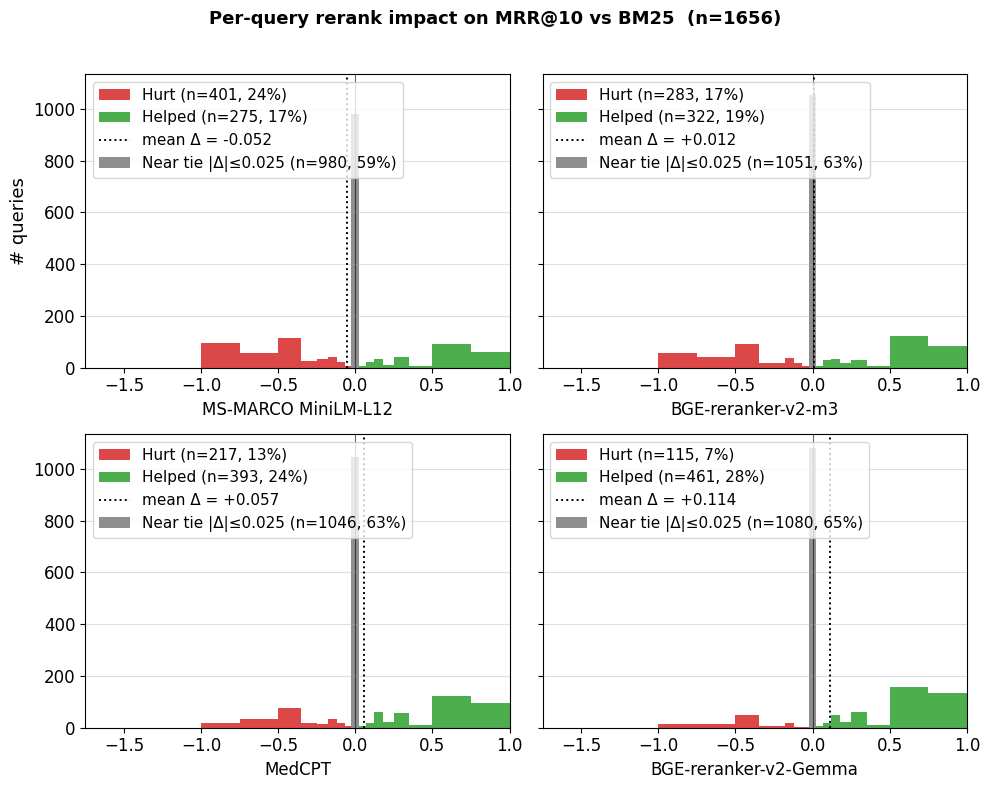

In [165]:
def _delta_arrays(rerank_run: dict[str, list[str]], k: int = 10):
    pq_b = _per_query_mrr_at_k(runs["ours_bm25"], qrels, k)
    pq_r = _per_query_mrr_at_k(rerank_run, qrels, k)
    common_q = [q for q in qrels if q in runs["ours_bm25"] and q in rerank_run]
    deltas = np.array([pq_r[q] - pq_b[q] for q in common_q], dtype=float)
    return common_q, pq_b, pq_r, deltas


bins = np.concatenate([
    # Edges at exactly ±1: MRR deltas lie in [-1, 1]; wider edges (e.g. -1.05) draw bars past ±1.
    np.array([-1.0, -0.75, -0.5, -0.35, -0.25, -0.18, -0.12, -0.07, -0.025]),
    np.array([0.025, 0.07, 0.12, 0.18, 0.25, 0.35, 0.5, 0.75, 1.0]),
])

# Horizontal range for ΔMRR: slightly wider left than bins gives margin so upper-left legend clears the x≈0 spike.
FIG_S3_XLIM = (-1.75, 1.0)

fig1b_panels_all = [
    ("frida_ms_marco_minilm_ce", "MS-MARCO MiniLM-L12"),
    ("ours_ce",                  "BGE-reranker-v2-m3"),
    ("vega_medcpt_ce",           "MedCPT"),
    ("frida_gemma_ce",           "BGE-reranker-v2-Gemma"),
]
fig1b_panels = [(k, l) for k, l in fig1b_panels_all if k in runs]

n_panels = len(fig1b_panels)
# 2×2 when four rerankers are present; fall back to a flat row if fewer.
if n_panels <= 1:
    fig, axes = plt.subplots(1, max(n_panels, 1), figsize=(5.5, 4.5), sharey=True)
    axes = np.atleast_1d(axes).ravel().tolist()
elif n_panels == 4:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
    axes = axes.ravel().tolist()
else:
    ncols = min(2, n_panels)
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes_arr = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), sharey=True)
    axes_flat = np.atleast_1d(axes_arr).ravel()
    for j in range(n_panels, len(axes_flat)):
        axes_flat[j].set_visible(False)
    axes = axes_flat[:n_panels].tolist()

print("Per-query MRR@10 Δ (rerank − BM25):")
for ax, (rerank_key, short_label) in zip(axes, fig1b_panels):
    _, _, _, deltas = _delta_arrays(runs[rerank_key], k=10)
    n_total = len(deltas)
    n_helped = int((deltas > 0).sum())
    n_hurt = int((deltas < 0).sum())
    n_unchanged = int((deltas == 0).sum())
    mean_help = float(deltas[deltas > 0].mean()) if n_helped else 0.0
    mean_hurt = float(deltas[deltas < 0].mean()) if n_hurt else 0.0
    mean_overall = float(deltas.mean())

    print(
        f"  {short_label:12s}  n={n_total}  "
        f"helped {n_helped} ({n_helped/n_total:.1%}, mean Δ +{mean_help:.4f})  "
        f"unchanged {n_unchanged}  "
        f"hurt {n_hurt} ({n_hurt/n_total:.1%}, mean Δ {mean_hurt:.4f})  "
        f"agg Δ {mean_overall:+.4f}"
    )

    hurt_m = deltas < -0.025
    help_m = deltas > 0.025
    neutral_m = ~(hurt_m | help_m)
    # Legend counts must match what is plotted: red/green histograms use |Δ|>0.025
    # only; the gray bar is all remaining queries in [-0.025, 0.025]. Do not mix
    # those with n_hurt/n_helped (any Δ<0 / Δ>0) or the three legend counts sum
    # to more than n (small-|Δ| queries would be double-counted).
    n_hurt_plot = int(hurt_m.sum())
    n_helped_plot = int(help_m.sum())
    n_neutral = int(neutral_m.sum())

    ax.hist(
        deltas[hurt_m], bins=bins, color="#d62728", alpha=0.85,
        label=f"Hurt (n={n_hurt_plot}, {n_hurt_plot/n_total:.0%})",
    )
    ax.hist(
        deltas[help_m], bins=bins, color="#2ca02c", alpha=0.85,
        label=f"Helped (n={n_helped_plot}, {n_helped_plot/n_total:.0%})",
    )
    ax.bar(
        [0], [n_neutral], width=0.05, color="#888888", alpha=0.95,
        label=f"Near tie |Δ|≤0.025 (n={n_neutral}, {n_neutral/n_total:.0%})",
    )
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.axvline(
        mean_overall, color="black", linestyle=":", linewidth=1.4,
        label=f"mean Δ = {mean_overall:+.3f}",
    )
    ax.set_xlabel(short_label, fontsize=12)
    ax.set_xlim(*FIG_S3_XLIM)
    ax.grid(True, axis="y", alpha=0.4)
    ax.legend(fontsize=11, loc="upper left")

axes[0].set_ylabel("# queries")
fig.suptitle(
    f"Per-query rerank impact on MRR@10 vs BM25  (n={len(qrels)})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig1b_path = paper_figures_dir / "fig_s3_per_query_rerank_delta.png"
plt.savefig(fig1b_path, dpi=150, bbox_inches="tight")
print("Saved:", fig1b_path)
plt.show()

In [166]:
# Worst-hurt-by-BGE-reranker-v2-m3 queries → CSV for qualitative inspection.
def _load_query_text_and_rel_abstracts_by_qid(
    path: Path, qrels_: dict[str, set[str]]
) -> tuple[dict[str, str], dict[str, str]]:
    texts: dict[str, str] = {}
    rel_abs: dict[str, str] = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            if not qid:
                continue
            texts[qid] = (q.get("query_text") or "").strip()
            rels = qrels_.get(qid)
            if not rels:
                continue
            parts: list[str] = []
            for d in q.get("docs") or []:
                pm = str(d.get("pmid") or "").strip()
                if pm not in rels:
                    continue
                ac = (d.get("abstract_clean") or "").strip()
                if ac:
                    parts.append(ac)
            rel_abs[qid] = "\n\n---\n\n".join(parts) if len(parts) > 1 else (parts[0] if parts else "")

    return texts, rel_abs


query_text_by_qid, rel_abstract_by_qid = _load_query_text_and_rel_abstracts_by_qid(goldset_jsonl, qrels)

common_qids_ce, pq_bm25_ce, pq_ce_ce, deltas_ce = _delta_arrays(runs["ours_ce"], k=10)
hurt_ranked = sorted(
    ((q, float(d)) for q, d in zip(common_qids_ce, deltas_ce) if d < 0),
    key=lambda t: t[1],
)
hurt_csv = output_dir / "worst_bge_v2_m3_hurt_queries.csv"
pd.DataFrame(
    [
        {
            "rank": i + 1,
            "query_id": q,
            "delta_mrr10_ce_minus_bm25": d,
            "mrr10_bm25": pq_bm25_ce[q],
            "mrr10_ce": pq_ce_ce[q],
            "query_text": query_text_by_qid.get(q, ""),
            "relevant_abstract_clean": rel_abstract_by_qid.get(q, ""),
        }
        for i, (q, d) in enumerate(hurt_ranked)
    ]
).to_csv(hurt_csv, index=False)
print(f"Wrote {len(hurt_ranked)} BGE-v2-m3-hurt queries (sorted worst-first): {hurt_csv}")

Wrote 285 BGE-v2-m3-hurt queries (sorted worst-first): /Users/yun/develop/dictycite/output/ragnarok_baseline/figures/worst_bge_v2_m3_hurt_queries.csv


## 12. Results paragraph (continued) — TBD pending combo results & framing

*Placeholder.* With MS-MARCO MiniLM-L12, BGE-reranker-v2-m3, MedCPT, and
BGE-reranker-v2-Gemma now in §11, the per-query distribution differs substantially across
rerankers — lightweight CE has many hurt queries, domain/strong CEs are
asymmetrically helpful. The paragraph for the paper will be drafted once the
QE × {MedCPT, BGE-reranker-v2-Gemma} combo runs land and the paper framing is locked.